## Simulation of BTD Model - (Auger, Bimolecular, Trapping, De-Trapping and Depopulation)

In [1]:
from globalfit_functions import *
import matplotlib.pyplot as plt

#### Define Simulation Parameters

In [2]:
#Time between 0 and 100 microseconds, logarithmically spaced
time = (jnp.logspace(0, np.log10(100001), 1000))-1

#Initial Carrier Densities
n0s = [1e14, 1e15, 1e16, 1e17, 1e18]

#Rate Constants
ka = 1e-37 #Auger
kt = 1e-17 #Trapping
kb = 1e-19 #Bimolecular
kdt = 1e-3 #Detrapping
kdp = 1e-19 #Depopulation Recombination
NT = 1e15 #Trap Density
p0 = 1e13 #Background Hole Density
bkg = 1e-5 #Background Signal

time_label = 'Time (ns)'
qfls_label = 'QFLS (eV)'
PL_label = 'PL (a.u.)'
diff_decay_label = fr'$\tau_{{diff}}$ (s)'
diff_const_label = fr'$k_{{diff}}$ ($cm^{{3}}s^{{-1}})$'


#### Simulate TRPL Decays and Differential Transformations

Simulating for n0 = 1.00e+14
Simulating for n0 = 1.00e+15
Simulating for n0 = 1.00e+16
Simulating for n0 = 1.00e+17
Simulating for n0 = 1.00e+18


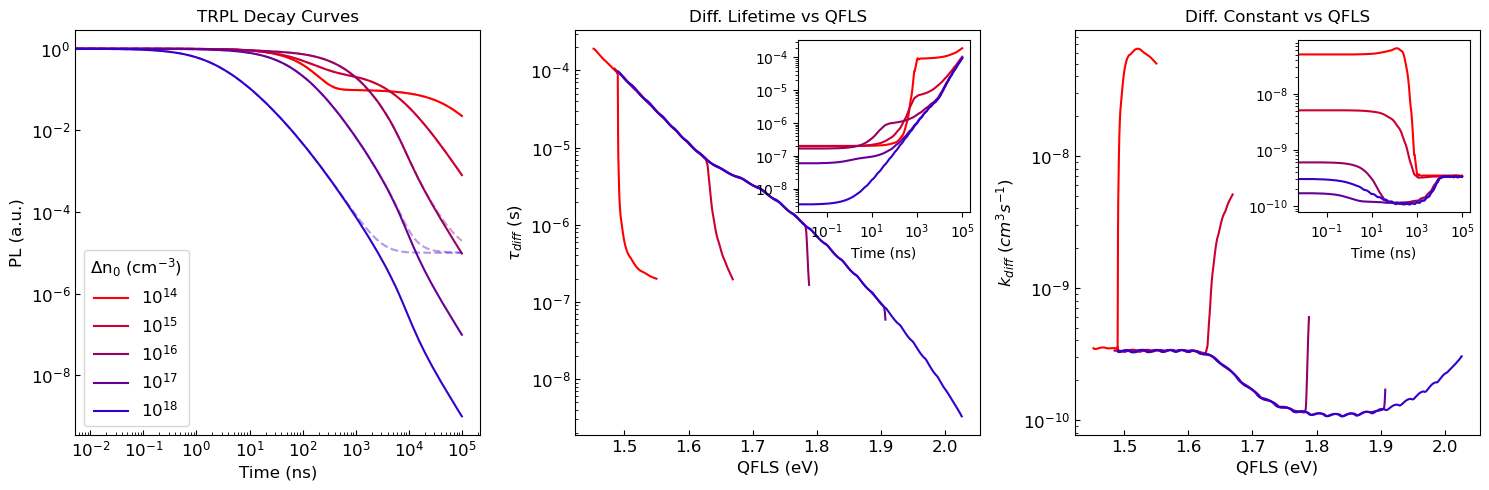

In [3]:
fig, ax = plt.subplots(1,3 , figsize=(15,5))
ax_inset_1 = ax[1].inset_axes([0.55, 0.55, 0.425, 0.425])
ax_inset_2 = ax[2].inset_axes([0.55, 0.55, 0.425, 0.425])
for i, n in enumerate(n0s):
    print(f'Simulating for n0 = {n:.2e}')
    color = colorFader('red', 'blue', factor=float(i)/len(n0s))

    trpl, n_e, n_p, n_t = TRPL_BTD(time, ka, kt, kb, kdt, kdp, NT, p0, n, 0)
    trpl_with_bkg = TRPL_BTD(time, ka, kt, kb, kdt, kdp, NT, p0, n, bkg)[0]
    trpl = 10**trpl
    trpl_with_bkg = 10**trpl_with_bkg
    ax[0].loglog(time, trpl_with_bkg/trpl_with_bkg[0], color=color, alpha=0.4, linestyle='dashed')
    ax[0].loglog(time, trpl/trpl[0], color=color, label =f'10$^{{{int(np.log10(n))}}}$')

    tau = diff_lifetime(time, trpl)
    d = diff_constant(time, trpl, n)
    qfls = relative_QFLS(trpl, n0=n, n0_max=n0s[0], eg=1.55)

    ax[1].semilogy(qfls, tau, color=color)
    ax_inset_1.loglog(time, tau, color=color)
    ax[2].semilogy(qfls, d, color=color)
    ax_inset_2.loglog(time, d, color=color)

ax[0].set_xlabel(time_label, fontsize='large')
ax[0].set_ylabel(PL_label, fontsize='large')
ax[0].set_title('TRPL Decay Curves')
ax[0].legend(title=fr'$\Delta$n$_0$ (cm$^{{-3}}$)', loc = 'lower left', fontsize='large', title_fontsize='large')
ax[1].set_xlabel(qfls_label, fontsize='large')
ax[1].set_ylabel(diff_decay_label, fontsize='large')
ax[1].set_title('Diff. Lifetime vs QFLS', fontsize='large')
ax_inset_1.set_xlabel(time_label, fontsize='medium')
ax_inset_2.set_xlabel(time_label, fontsize='medium')
ax[2].set_xlabel(qfls_label, fontsize='large')
ax[2].set_ylabel(diff_const_label, fontsize='large')
ax[2].set_title('Diff. Constant vs QFLS', fontsize='large')
ax[0].tick_params(axis='both', which='both', labelsize='large', direction='in')
ax[1].tick_params(axis='both', which='both', labelsize='large', direction='in')
ax[2].tick_params(axis='both', which='both', labelsize='large', direction='in')

fig.tight_layout()

#### Simulate Charge Carriers

<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:17: SyntaxWarning: invalid escape sequence '\D'
C:\Users\barne\AppData\Local\Temp\ipykernel_19324\542481131.py:17: SyntaxWarning: invalid escape sequence '\D'
  ax[i//2].set_title(f'Carrier Densities for $\Delta$n$_0$ = 10$^{{{int(np.log10(n))}}}$ cm$^{{-3}}$', fontsize='x-large')


Simulating for n0 = 1.00e+14
Simulating for n0 = 1.00e+16
Simulating for n0 = 1.00e+18


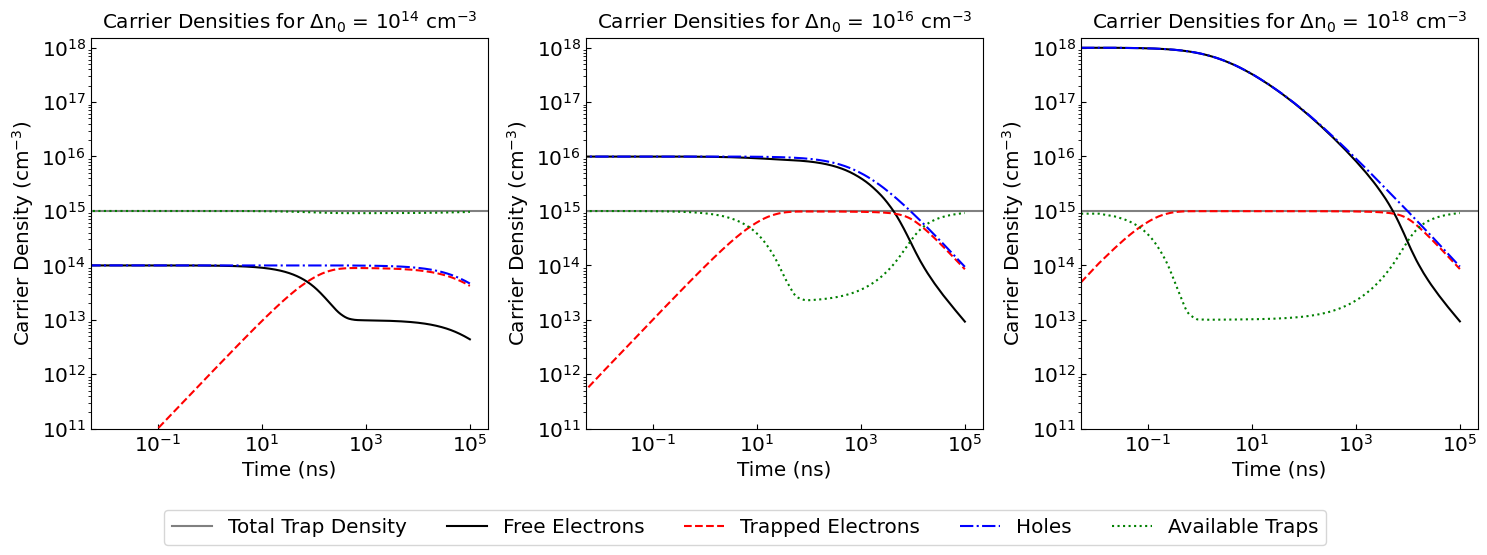

In [4]:
fig, ax = plt.subplots(1,3 , figsize=(15,5))
for i, n in enumerate(n0s):
    if i % 2 == 0:
        print(f'Simulating for n0 = {n:.2e}')
        color = colorFader('red', 'blue', factor=float(i)/len(n0s))

        trpl, n_e, n_p, n_t = TRPL_BTD(time, ka, kt, kb, kdt, kdp, NT, p0, n, 0)
        available_traps = NT - n_t

        ax[i//2].axhline(NT, color='grey', label='Total Trap Density')
        ax[i//2].loglog(time, n_e, color='black', label =f'10$^{{{int(np.log10(n))}}}$')
        ax[i//2].loglog(time, n_t, color='red', linestyle='dashed')
        ax[i//2].loglog(time, n_p, color='blue', linestyle='dashdot')
        ax[i//2].loglog(time, available_traps, color='green', linestyle='dotted')
        ax[i//2].set_xlabel(time_label, fontsize='x-large')
        ax[i//2].set_ylabel(r'Carrier Density (cm$^{-3}$)', fontsize='x-large')
        ax[i//2].set_title(f'Carrier Densities for $\Delta$n$_0$ = 10$^{{{int(np.log10(n))}}}$ cm$^{{-3}}$', fontsize='x-large')
        ax[i//2].set_ylim(1e11,1.5e18)
        ax[i//2].tick_params(axis='both', which='major', labelsize='x-large', direction='in')
fig.legend(['Total Trap Density', 'Free Electrons', 'Trapped Electrons', 'Holes', 'Available Traps'], fontsize='x-large', ncols=5, loc='upper center', bbox_to_anchor=(0.5, -0.01))
fig.tight_layout()

#### Contributions of Each Physical Process

<>:22: SyntaxWarning: invalid escape sequence '\D'
<>:22: SyntaxWarning: invalid escape sequence '\D'
C:\Users\barne\AppData\Local\Temp\ipykernel_19324\1369962852.py:22: SyntaxWarning: invalid escape sequence '\D'
  ax[i//2].set_title(f'Decay Contributions for $\Delta$n$_0$ = 10$^{{{int(np.log10(n))}}}$ cm$^{{-3}}$', fontsize='x-large')


Simulating for n0 = 1.00e+14


C:\Users\barne\AppData\Local\Temp\ipykernel_19324\1369962852.py:25: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax[i//2].set_xlim(0,1e5)


Simulating for n0 = 1.00e+16
Simulating for n0 = 1.00e+18


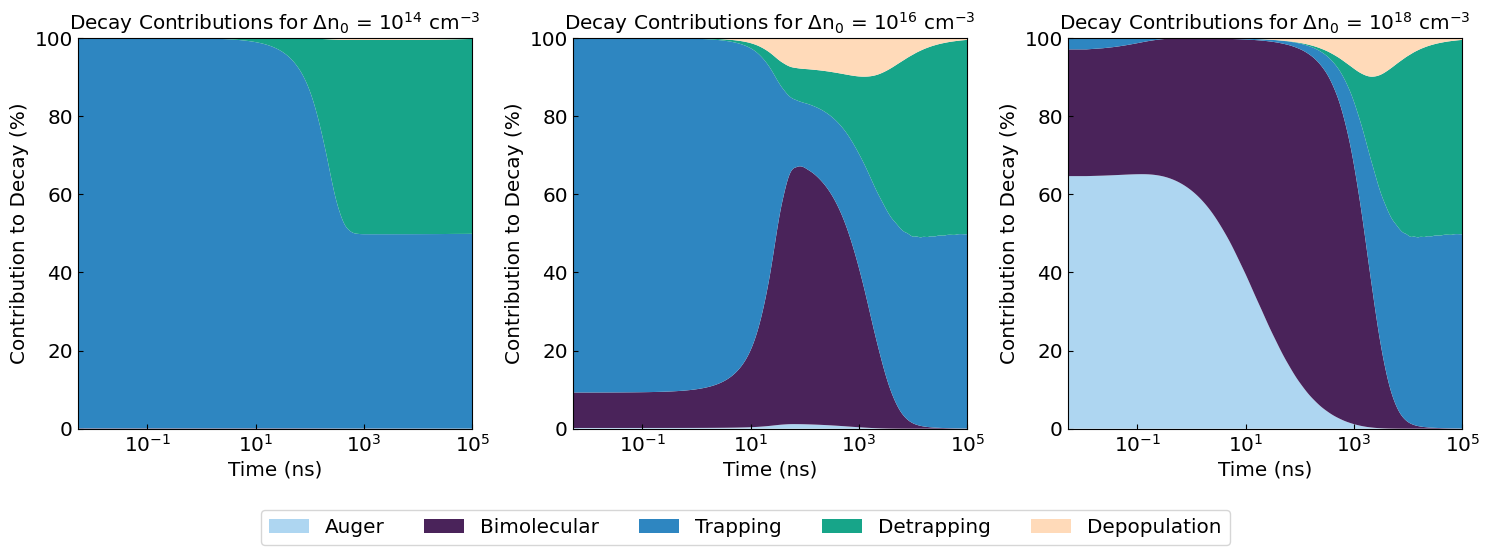

In [5]:
planner2_colors = ['#AED6F1', '#4A235A', '#2E86C1', '#17A589', '#FFDAB9']
fig, ax = plt.subplots(1,3 , figsize=(15,5))
for i, n in enumerate(n0s):
    if i % 2 == 0:
        print(f'Simulating for n0 = {n:.2e}')
        color = planner2_colors[i]

        trpl, n_e, n_p, n_t = TRPL_BTD(time, ka, kt, kb, kdt, kdp, NT, p0, n, 0)
        auger = ka * (n_e**2 * n_p + n_e * n_p**2)
        bimolecular = kb * n_e * n_p
        trapping = kt * n_e * (NT - n_t)
        detrapping = kdt * n_t
        depopulation = kdp * n_p * n_t

        total = auger + bimolecular + trapping + detrapping + depopulation

        auger_norm, bimolecular_norm, trapping_norm, detrapping_norm, depopulation_norm = [100*x/total for x in [auger, bimolecular, trapping, detrapping, depopulation]]

        ax[i//2].stackplot(time, auger_norm, bimolecular_norm, trapping_norm, detrapping_norm, depopulation_norm, colors=planner2_colors, labels=['Auger', 'Bimolecular', 'Trapping', 'Detrapping', 'Depopulation'])
        ax[i//2].set_xlabel(time_label, fontsize='x-large')
        ax[i//2].set_ylabel('Contribution to Decay (%)', fontsize='x-large')
        ax[i//2].set_title(f'Decay Contributions for $\Delta$n$_0$ = 10$^{{{int(np.log10(n))}}}$ cm$^{{-3}}$', fontsize='x-large')
        ax[i//2].set_ylim(0,100)
        ax[i//2].set_xscale('log')
        ax[i//2].set_xlim(0,1e5)
        ax[i//2].tick_params(axis='both', which='major', labelsize='x-large', direction='in')
fig.legend(['Auger', 'Bimolecular', 'Trapping', 'Detrapping', 'Depopulation'], fontsize='x-large', ncols=5, loc='upper center', bbox_to_anchor=(0.5, -0.01))
fig.tight_layout()

Effect of kT

Simulating for kT = 1.00e-16
Simulating for kT = 1.00e-17
Simulating for kT = 1.00e-18


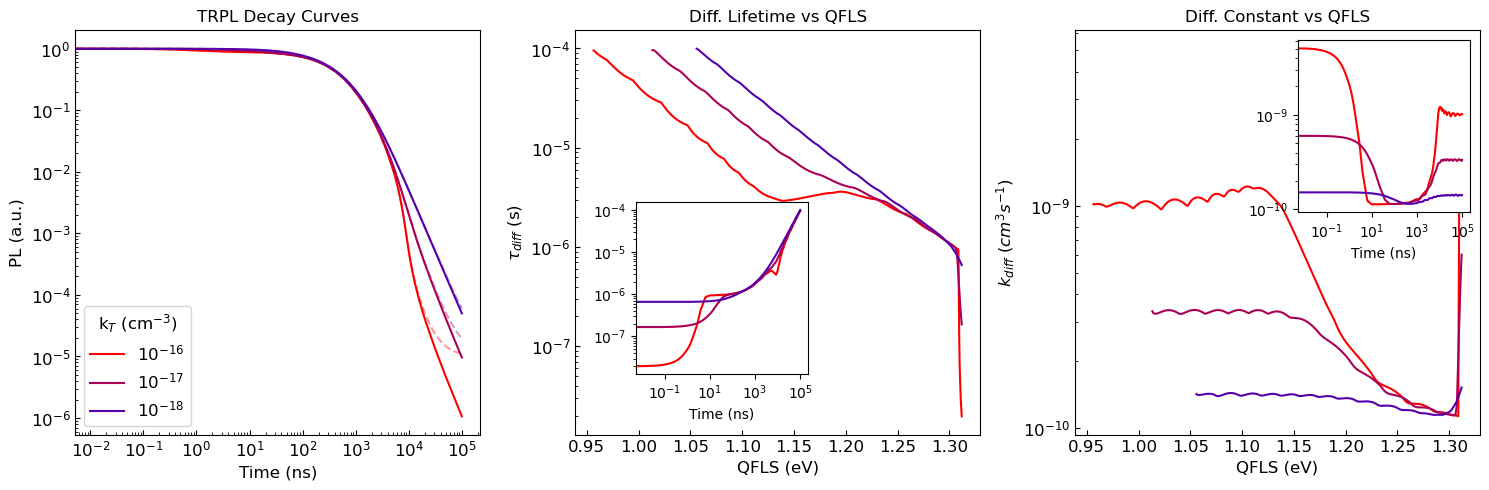

In [6]:
kts = [1e-16, 1e-17, 1e-18]
n0 = 1e16
fig, ax = plt.subplots(1,3 , figsize=(15,5))
ax_inset_1 = ax[1].inset_axes([0.15, 0.15, 0.425, 0.425])
ax_inset_2 = ax[2].inset_axes([0.55, 0.55, 0.425, 0.425])
for i, kt in enumerate(kts):
    print(f'Simulating for kT = {kt:.2e}')
    color = colorFader('red', 'blue', factor=float(i)/len(kts))

    trpl, n_e, n_p, n_t = TRPL_BTD(time, ka, kt, kb, kdt, kdp, NT, p0, n0, 0)
    trpl_with_bkg = TRPL_BTD(time, ka, kt, kb, kdt, kdp, NT, p0, n0, bkg)[0]
    trpl = 10**trpl
    trpl_with_bkg = 10**trpl_with_bkg
    ax[0].loglog(time, trpl_with_bkg/trpl_with_bkg[0], color=color, alpha=0.4, linestyle='dashed')
    ax[0].loglog(time, trpl/trpl[0], color=color, label =f'10$^{{{int(np.log10(kt))}}}$')

    tau = diff_lifetime(time, trpl)
    d = diff_constant(time, trpl, n0)
    qfls = relative_QFLS(trpl, n0=n0, n0_max=1e18, eg=1.55)

    ax[1].semilogy(qfls, tau, color=color)
    ax_inset_1.loglog(time, tau, color=color)
    ax[2].semilogy(qfls, d, color=color)
    ax_inset_2.loglog(time, d, color=color)

ax[0].set_xlabel(time_label, fontsize='large')
ax[0].set_ylabel(PL_label, fontsize='large')
ax[0].set_title('TRPL Decay Curves')
ax[0].legend(title=fr'k$_T$ (cm$^{{-3}}$)', loc = 'lower left', fontsize='large', title_fontsize='large')
ax[1].set_xlabel(qfls_label, fontsize='large')
ax[1].set_ylabel(diff_decay_label, fontsize='large')
ax[1].set_title('Diff. Lifetime vs QFLS', fontsize='large')
ax_inset_1.set_xlabel(time_label, fontsize='medium')
ax_inset_2.set_xlabel(time_label, fontsize='medium')
ax[2].set_xlabel(qfls_label, fontsize='large')
ax[2].set_ylabel(diff_const_label, fontsize='large')
ax[2].set_title('Diff. Constant vs QFLS', fontsize='large')
ax[0].tick_params(axis='both', which='both', labelsize='large', direction='in')
ax[1].tick_params(axis='both', which='both', labelsize='large', direction='in')
ax[2].tick_params(axis='both', which='both', labelsize='large', direction='in')

fig.tight_layout()

Simulating for NT = 1.00e+14
Simulating for NT = 1.00e+15
Simulating for NT = 1.00e+16
Simulating for NT = 1.00e+17


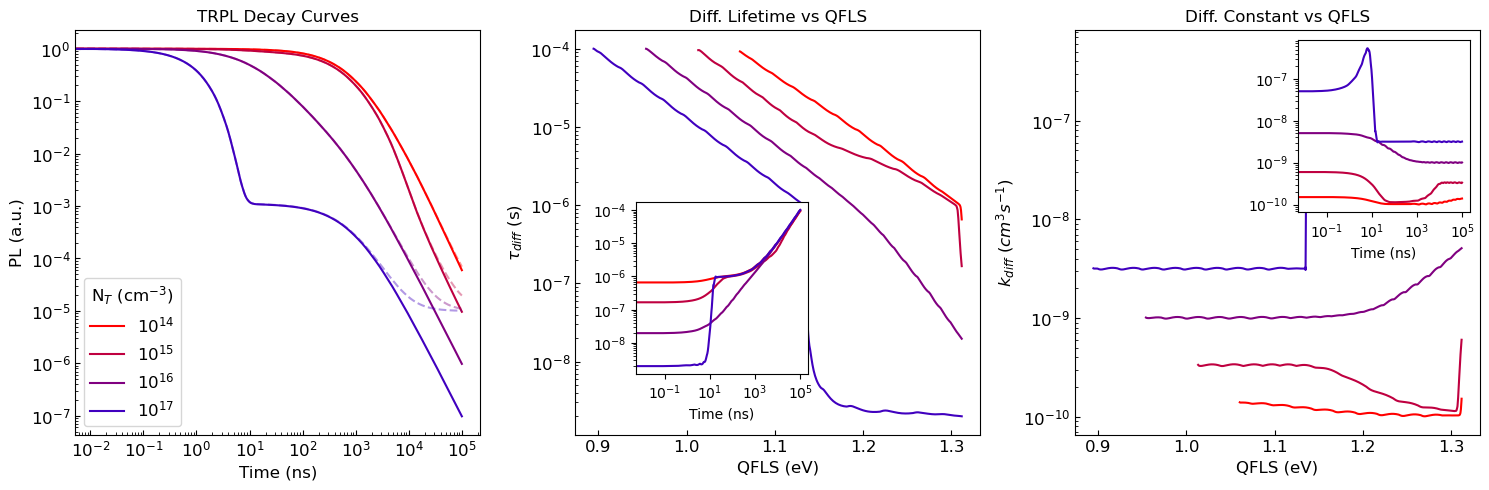

In [7]:
NTs = [1e14, 1e15, 1e16, 1e17]
n0 = 1e16
kt = 1e-17
fig, ax = plt.subplots(1,3 , figsize=(15,5))
ax_inset_1 = ax[1].inset_axes([0.15, 0.15, 0.425, 0.425])
ax_inset_2 = ax[2].inset_axes([0.55, 0.55, 0.425, 0.425])
for i, NT in enumerate(NTs):
    print(f'Simulating for NT = {NT:.2e}')
    color = colorFader('red', 'blue', factor=float(i)/len(NTs))

    trpl, n_e, n_p, n_t = TRPL_BTD(time, ka, kt, kb, kdt, kdp, NT, p0, n0, 0)
    trpl_with_bkg = TRPL_BTD(time, ka, kt, kb, kdt, kdp, NT, p0, n0, bkg)[0]
    trpl = 10**trpl
    trpl_with_bkg = 10**trpl_with_bkg
    ax[0].loglog(time, trpl_with_bkg/trpl_with_bkg[0], color=color, alpha=0.4, linestyle='dashed')
    ax[0].loglog(time, trpl/trpl[0], color=color, label =f'10$^{{{int(np.log10(NT))}}}$')

    tau = diff_lifetime(time, trpl)
    d = diff_constant(time, trpl, n0)
    qfls = relative_QFLS(trpl, n0=n0, n0_max=1e18, eg=1.55)

    ax[1].semilogy(qfls, tau, color=color)
    ax_inset_1.loglog(time, tau, color=color)
    ax[2].semilogy(qfls, d, color=color)
    ax_inset_2.loglog(time, d, color=color)

ax[0].set_xlabel(time_label, fontsize='large')
ax[0].set_ylabel(PL_label, fontsize='large')
ax[0].set_title('TRPL Decay Curves')
ax[0].legend(title=fr'N$_T$ (cm$^{{-3}}$)', loc = 'lower left', fontsize='large', title_fontsize='large')
ax[1].set_xlabel(qfls_label, fontsize='large')
ax[1].set_ylabel(diff_decay_label, fontsize='large')
ax[1].set_title('Diff. Lifetime vs QFLS', fontsize='large')
ax_inset_1.set_xlabel(time_label, fontsize='medium')
ax_inset_2.set_xlabel(time_label, fontsize='medium')
ax[2].set_xlabel(qfls_label, fontsize='large')
ax[2].set_ylabel(diff_const_label, fontsize='large')
ax[2].set_title('Diff. Constant vs QFLS', fontsize='large')
ax[0].tick_params(axis='both', which='both', labelsize='large', direction='in')
ax[1].tick_params(axis='both', which='both', labelsize='large', direction='in')
ax[2].tick_params(axis='both', which='both', labelsize='large', direction='in')

fig.tight_layout()

Simulating for kdp = 1.00e-18
Simulating for kdp = 1.00e-19
Simulating for kdp = 1.00e-20


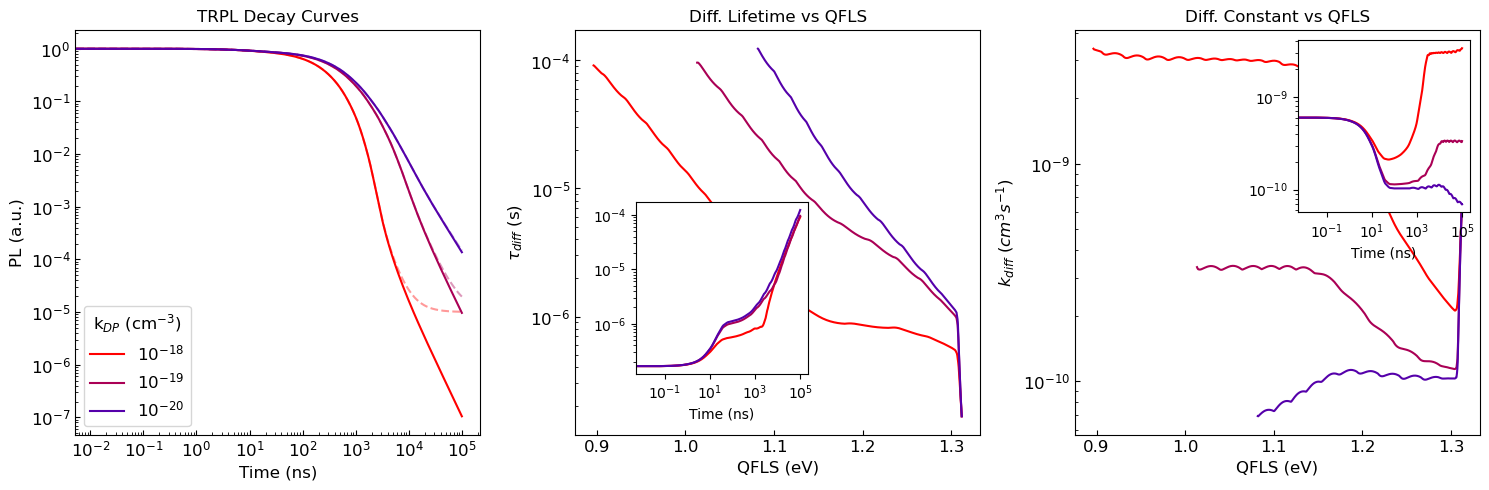

In [8]:
kdps = [1e-18, 1e-19, 1e-20]
n0 = 1e16
NT=1e15
fig, ax = plt.subplots(1,3 , figsize=(15,5))
ax_inset_1 = ax[1].inset_axes([0.15, 0.15, 0.425, 0.425])
ax_inset_2 = ax[2].inset_axes([0.55, 0.55, 0.425, 0.425])
for i, kdp in enumerate(kdps):
    print(f'Simulating for kdp = {kdp:.2e}')
    color = colorFader('red', 'blue', factor=float(i)/len(kdps))

    trpl, n_e, n_p, n_t = TRPL_BTD(time, ka, kt, kb, kdt, kdp, NT, p0, n0, 0)
    trpl_with_bkg = TRPL_BTD(time, ka, kt, kb, kdt, kdp, NT, p0, n0, bkg)[0]
    trpl = 10**trpl
    trpl_with_bkg = 10**trpl_with_bkg
    ax[0].loglog(time, trpl_with_bkg/trpl_with_bkg[0], color=color, alpha=0.4, linestyle='dashed')
    ax[0].loglog(time, trpl/trpl[0], color=color, label =f'10$^{{{int(np.log10(kdp))}}}$')

    tau = diff_lifetime(time, trpl)
    d = diff_constant(time, trpl, n0)
    qfls = relative_QFLS(trpl, n0=n0, n0_max=1e18, eg=1.55)

    ax[1].semilogy(qfls, tau, color=color)
    ax_inset_1.loglog(time, tau, color=color)
    ax[2].semilogy(qfls, d, color=color)
    ax_inset_2.loglog(time, d, color=color)

ax[0].set_xlabel(time_label, fontsize='large')
ax[0].set_ylabel(PL_label, fontsize='large')
ax[0].set_title('TRPL Decay Curves')
ax[0].legend(title=fr'k$_{{DP}}$ (cm$^{{-3}}$)', loc = 'lower left', fontsize='large', title_fontsize='large')
ax[1].set_xlabel(qfls_label, fontsize='large')
ax[1].set_ylabel(diff_decay_label, fontsize='large')
ax[1].set_title('Diff. Lifetime vs QFLS', fontsize='large')
ax_inset_1.set_xlabel(time_label, fontsize='medium')
ax_inset_2.set_xlabel(time_label, fontsize='medium')
ax[2].set_xlabel(qfls_label, fontsize='large')
ax[2].set_ylabel(diff_const_label, fontsize='large')
ax[2].set_title('Diff. Constant vs QFLS', fontsize='large')
ax[0].tick_params(axis='both', which='both', labelsize='large', direction='in')
ax[1].tick_params(axis='both', which='both', labelsize='large', direction='in')
ax[2].tick_params(axis='both', which='both', labelsize='large', direction='in')

fig.tight_layout()